In [158]:
import numpy as np
import matplotlib.pyplot as plt

In [159]:
examples = np.array([[[1,1,1,-1],   # T Shifted Left
                    [-1,1,-1,-1],
                    [-1,1,-1,-1],
                    [-1,1,-1,-1]],
                   [[-1,1,1,1],   # T Shifted Right
                    [-1,-1,1,-1],
                    [-1,-1,1,-1],
                    [-1,-1,1,-1]],
                   [[-1,-1,1,-1], # J Shifted Left
                    [-1,-1,1,-1],
                    [1,-1,1,-1],
                    [1,1,1,-1]],
                   [[-1,-1,-1,1], # J Shifted Right
                    [-1,-1,-1,1],
                    [-1,1,-1,1],
                    [-1,1,1,1]]])

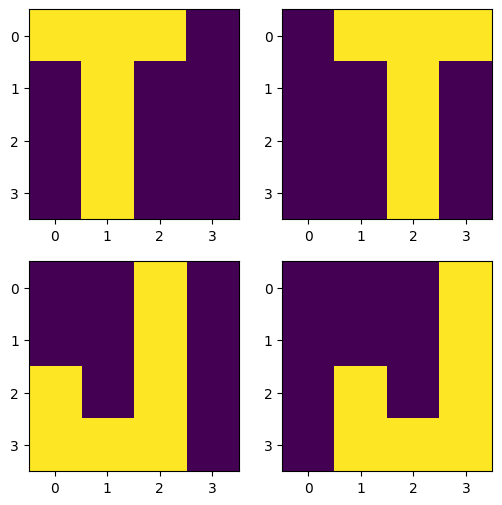

In [160]:
fig=plt.figure(0,(6, 6))
for i in range(len(examples)):
            fig.add_subplot(2,2,i+1)
            plt.imshow(examples[i])

In [161]:
y = np.array([1, 1, -1, -1])
X = np.hstack((examples.reshape(-1, 16), np.ones((len(y), 1))))
# X = np.hstack((examples.reshape(-1, 16), np.array([2, 4, 6, 8]).reshape(len(y), 1)))
X.shape, y.shape

((4, 17), (4,))

In [162]:
X

array([[ 1.,  1.,  1., -1., -1.,  1., -1., -1., -1.,  1., -1., -1., -1.,
         1., -1., -1.,  1.],
       [-1.,  1.,  1.,  1., -1., -1.,  1., -1., -1., -1.,  1., -1., -1.,
        -1.,  1., -1.,  1.],
       [-1., -1.,  1., -1., -1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.,
         1.,  1., -1.,  1.],
       [-1., -1., -1.,  1., -1., -1., -1.,  1., -1.,  1., -1.,  1., -1.,
         1.,  1.,  1.,  1.]])

In [163]:
w = np.zeros(17)
lr = 1.0

In [164]:
i = 1
yhat = np.dot(X[i], w)
yhat, y[i]

(np.float64(0.0), np.int64(1))

In [165]:
w = w + lr * X[i]

In [166]:
w[:16].reshape(4, 4)

array([[-1.,  1.,  1.,  1.],
       [-1., -1.,  1., -1.],
       [-1., -1.,  1., -1.],
       [-1., -1.,  1., -1.]])

In [167]:
i += 1
i

2

In [168]:
yhat = np.dot(X[i], w)
yhat, y[i]

(np.float64(7.0), np.int64(-1))

In [169]:
w= w-lr*X[i]
w[:16].reshape(4, 4)

array([[ 0.,  2.,  0.,  2.],
       [ 0.,  0.,  0.,  0.],
       [-2.,  0.,  0.,  0.],
       [-2., -2.,  0.,  0.]])

In [170]:
i += 1
i

3

In [171]:
yhat = np.dot(X[i], w)
yhat, y[i]

(np.float64(2.0), np.int64(-1))

In [172]:
w = w - lr * X[i]
w[:16].reshape(4, 4)

array([[ 1.,  3.,  1.,  1.],
       [ 1.,  1.,  1., -1.],
       [-1., -1.,  1., -1.],
       [-1., -3., -1., -1.]])

In [173]:
i = 0

In [174]:
yhat = np.dot(X[i], w)
yhat, y[i]

(np.float64(3.0), np.int64(1))

In [175]:
for i in range(4):
	yhat = np.dot(X[i], w)
	print(yhat, y[i])

3.0 1
11.0 1
-7.0 -1
-15.0 -1


In [176]:
# two input perceptron
examples=np.array([[[-1,-1]],
             [[-1,1]],
             [[1,-1]],
             [[1,1]]])

y = np.array([-1, 1, 1, 1])

X = np.hstack((examples.reshape(-1, 2), np.ones((len(y), 1))))
w = np.zeros(3)
lr = 1.0

In [177]:
X, w, y

(array([[-1., -1.,  1.],
        [-1.,  1.,  1.],
        [ 1., -1.,  1.],
        [ 1.,  1.,  1.]]),
 array([0., 0., 0.]),
 array([-1,  1,  1,  1]))

In [178]:
for i in range(1, 12):
	print(f"step: {i}, current example: {X[i%len(y)][:2]}, current weights = {w}")
	if yhat<=0 and y[i%len(y)]>0:
			print(f"output is {yhat} but we want it to be {y[i%len(y)]}, updating weights.")
			w=w+lr*X[i%len(y)]
	elif yhat>0 and y[i%len(y)]<=0:
		print(f"output is {yhat} but we want it to be {y[i%len(y)]}, updating weights.")
		w=w-lr*X[i%len(y)]
	else:
		print(f"output is {yhat}, which has the same sign as our target {y[i%len(y)]},"
			f"machine is correct, not updating weights.")

step: 1, current example: [-1.  1.], current weights = [0. 0. 0.]
output is -15.0 but we want it to be 1, updating weights.
step: 2, current example: [ 1. -1.], current weights = [-1.  1.  1.]
output is -15.0 but we want it to be 1, updating weights.
step: 3, current example: [1. 1.], current weights = [0. 0. 2.]
output is -15.0 but we want it to be 1, updating weights.
step: 4, current example: [-1. -1.], current weights = [1. 1. 3.]
output is -15.0, which has the same sign as our target -1,machine is correct, not updating weights.
step: 5, current example: [-1.  1.], current weights = [1. 1. 3.]
output is -15.0 but we want it to be 1, updating weights.
step: 6, current example: [ 1. -1.], current weights = [0. 2. 4.]
output is -15.0 but we want it to be 1, updating weights.
step: 7, current example: [1. 1.], current weights = [1. 1. 5.]
output is -15.0 but we want it to be 1, updating weights.
step: 8, current example: [-1. -1.], current weights = [2. 2. 6.]
output is -15.0, which ha

Text(0.5, 0.92, 'Perceptron Error Surface\n(Linearly Separable Case)')

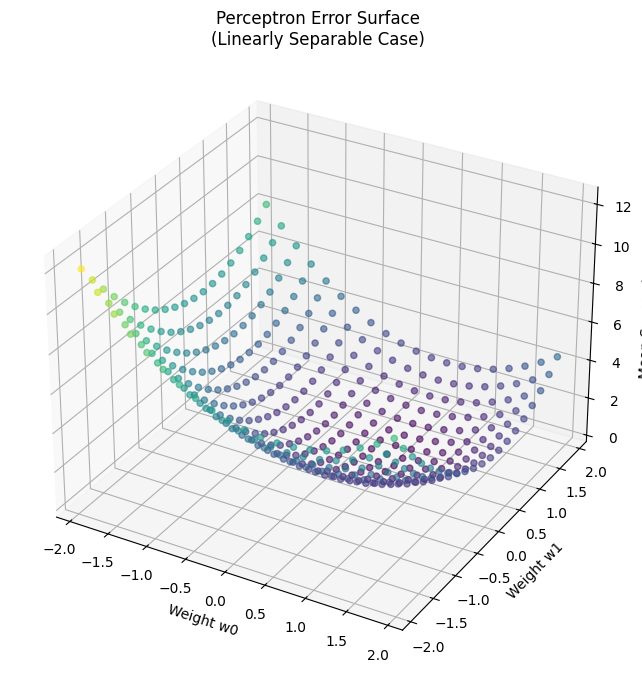

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Linearly Separable case
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y = np.array([[-1], [1], [1], [1]])
w0_range = np.arange(-1.9, 2.0, 0.2)
w1_range = np.arange(-1.9, 2.0, 0.2)
b = 1 # Bias term
# Initialize lists to store results
w0_points = []
w1_points = []
error_points = []
# Compute error for each weight combination
for w0 in w0_range:
    for w1 in w1_range:
        yhat = X[:,0]*w0 + X[:,1]*w1 + b # Compute all 4 yhats at once
        error = np.mean((y.ravel() - yhat)**2) # Mean squared error
        # Store the results
        w0_points.append(w0)
        w1_points.append(w1)
        error_points.append(error)
# Convert to numpy arrays
w0_points = np.array(w0_points)
w1_points = np.array(w1_points)
error_points = np.array(error_points)
# Create 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# Create scatter plot with color mapping
scatter = ax.scatter(w0_points, w1_points, error_points,
                    c=error_points, cmap='viridis',
                    alpha=0.6, s=20)
# Add labels and title
ax.set_xlabel('Weight w0')
ax.set_ylabel('Weight w1')
ax.set_zlabel('Mean Squared Error')
ax.set_title('Perceptron Error Surface\n(Linearly Separable Case)')

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
X = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

class XORNet(nn.Module):
	def __init__(self):
		super(XORNet, self).__init__()
		self.hidden = nn.Linear(2, 2)
		self.output = nn.Linear(2, 1)
		self.sigmoid = nn.Sigmoid()

	def forward(self, x):
		x = self.sigmoid(self.hidden(x))
		x = self.sigmoid(self.output(x))
		return x

model = XORNet()
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr = 0.1)

for epoch in range(1000):
	optimizer.zero_grad()
	outputs = model(X)
	loss = criterion(outputs, y)
	loss.backward()
	optimizer.step()

	if epoch % 100 == 0:
		print(f'Epoch {epoch}, loss: {loss.item():.4f}')

print("\nresults:")
with torch.no_grad():
	for i in range(len(X)):
		output = model(X[i:i+1])
		print(f"input: {X[i].numpy()}, target: {y[i].item()}, output: {output.item():.4f}")

Epoch 0, loss: 0.2509
Epoch 100, loss: 0.0039
Epoch 200, loss: 0.0018
Epoch 300, loss: 0.0013
Epoch 400, loss: 0.0010
Epoch 500, loss: 0.0009
Epoch 600, loss: 0.0008
Epoch 700, loss: 0.0007
Epoch 800, loss: 0.0006
Epoch 900, loss: 0.0006

results:
input: [0. 0.], target: 0.0, output: 0.0231
input: [0. 1.], target: 1.0, output: 0.9790
input: [1. 0.], target: 1.0, output: 0.9746
input: [1. 1.], target: 0.0, output: 0.0207
